# 01. HRV Baseline Models – WESAD

In [53]:
from pathlib import Path
import pandas as pd

# Force project_root to always be repo base (one level up from notebooks/)
project_root = Path.cwd().resolve()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

wesad_file = processed_dir / "WESAD_HRV_features.csv"
if not wesad_file.exists():
    raise FileNotFoundError(f"❌ {wesad_file} not found. Run 00 first to generate it.")

wesad = pd.read_csv(wesad_file)

print("✅ Loaded WESAD features from:", wesad_file.resolve())
print("Shape:", wesad.shape)
print("Columns:", wesad.columns.tolist()[:10])


✅ Loaded WESAD features from: C:\Users\Sunil\Projects\HRV-GenAI\data\processed\WESAD_HRV_features.csv
Shape: (45, 38)
Columns: ['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD']


In [54]:
# =====================================================
# 2. Prepare Features & Labels
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ["HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_LF", "HRV_HF", "HRV_LFHF"]

X = wesad[feature_cols]
y = wesad["Label"]

print("Feature matrix shape:", X.shape)
print("Label distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Split into train/test and scaled features")

Feature matrix shape: (45, 6)
Label distribution:
 Label
1    15
2    15
3    15
Name: count, dtype: int64
✅ Split into train/test and scaled features


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ["HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_LF", "HRV_HF", "HRV_LFHF"]

X = wesad[feature_cols]
y = wesad["Label"]

# Drop rows where any HRV feature is NaN
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("✅ Dropped rows with NaNs, remaining shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


✅ Dropped rows with NaNs, remaining shape: (45, 6)


In [43]:
# =====================================================
# 3. Train Models (LogReg, RF, SVM)
# =====================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

logreg = LogisticRegression(max_iter=1000, multi_class="ovr")
rf = RandomForestClassifier(n_estimators=200, random_state=42)
svm = SVC(probability=True, kernel="rbf", random_state=42)

logreg.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)

models = {"LogReg": logreg, "RandomForest": rf, "SVM": svm}
print("✅ Trained models: LogReg, RandomForest, SVM")

C:\Users\Sunil\Projects\HRV-GenAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Trained models: LogReg, RandomForest, SVM


In [56]:
# =====================================================
# 4. Evaluate Models
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    try:
        roc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    except:
        roc = np.nan
    
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": roc})

results_df = pd.DataFrame(results)
display(results_df)

out_file = results_dir / "wesad_baseline_results_eval.csv"
results_df.to_csv(out_file, index=False)
print("✅ Saved results to", out_file)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogReg,0.500000,0.653061,0.500000,0.522263,0.807407
1,RandomForest,0.714286,0.738095,0.714286,0.720058,0.781481
2,SVM,0.571429,0.690476,0.571429,0.578108,0.853704


✅ Saved results to C:\Users\Sunil\Projects\HRV-GenAI\results\wesad_baseline_results_eval.csv


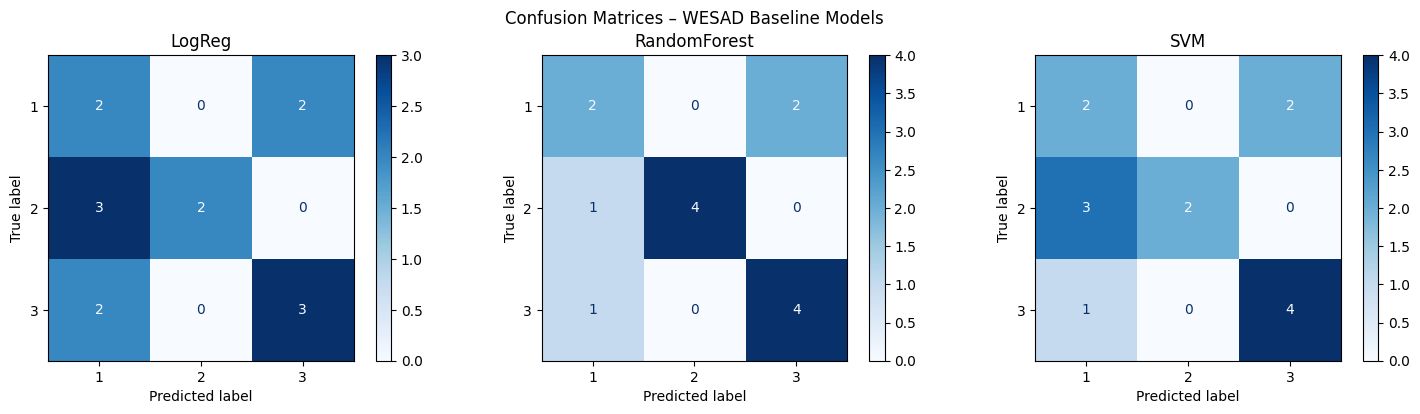

✅ Saved confusion matrices plot


In [57]:
# =====================================================
# 5. Confusion Matrices
# =====================================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1,3,i)
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, cmap="Blues", ax=plt.gca())
    plt.title(name)
plt.suptitle("Confusion Matrices – WESAD Baseline Models")
plt.tight_layout()
plt.savefig(results_dir / "wesad_baseline_confusion_matrices.png", dpi=300)
plt.show()
print("✅ Saved confusion matrices plot")

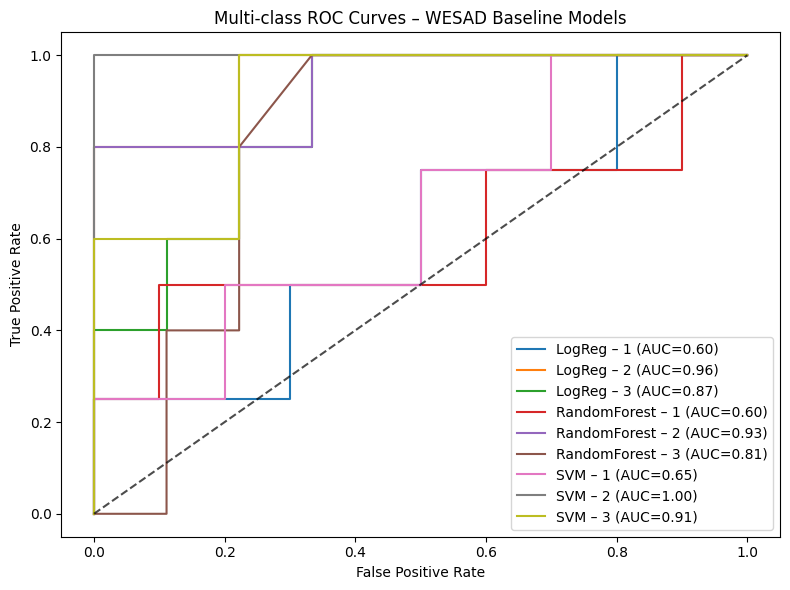

✅ Saved multi-class ROC curves to C:\Users\Sunil\Projects\HRV-GenAI\results\wesad_baseline_multiclass_roc.png


In [46]:
# =====================================================
# 6. Multi-class ROC Curves (OvR)
# =====================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels (one-vs-rest)
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Get predicted probabilities
    y_score = model.predict_proba(X_test_scaled)

    # Compute ROC curve and AUC for each class
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} – {cls} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves – WESAD Baseline Models")
plt.legend()
plt.tight_layout()

out_file = results_dir / "wesad_baseline_multiclass_roc.png"
plt.savefig(out_file, dpi=300)
plt.show()

print(f"✅ Saved multi-class ROC curves to {out_file}")


In [59]:
print("Available variables in this notebook:")
for var in dir():
    if not var.startswith("_"):
        print(var)


Available variables in this notebook:
ConfusionMatrixDisplay
In
LogisticRegression
Out
Path
RandomForestClassifier
SVC
StandardScaler
X
X_test
X_test_scaled
X_train
X_train_scaled
acc
accuracy_score
auc
classes
cls
data_dir
exit
f1
f1_score
feature_cols
fpr
get_ipython
i
label_binarize
logreg
mask
model
models
name
np
open
out_file
p
pd
plt
prec
precision_score
processed_dir
project_root
quit
rec
recall_score
results
results_df
results_dir
rf
roc
roc_auc
roc_auc_score
roc_curve
scaler
svm
tpr
train_test_split
wesad
wesad_file
y
y_pred
y_prob
y_score
y_test
y_test_bin
y_train


In [60]:
# =====================================================
# 6. Save baseline results for WESAD
# =====================================================

# results_df is already in memory
print("✅ Baseline results DataFrame shape:", results_df.shape)
print("Columns:", results_df.columns.tolist())

# Save WESAD results
wesad_results_file = results_dir / "wesad_baseline_results.csv"
results_df.to_csv(wesad_results_file, index=False)
print(f"✅ Saved baseline results to {wesad_results_file}")


✅ Baseline results DataFrame shape: (3, 6)
Columns: ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Sunil\\Projects\\HRV-GenAI\\results\\wesad_baseline_results.csv'

In [61]:
wesad_results_file = results_dir / "wesad_baseline_results.csv"
results_df.to_csv(wesad_results_file, index=False)

print("✅ Saved baseline results to:", wesad_results_file.resolve())
print("File exists? ->", wesad_results_file.exists())


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Sunil\\Projects\\HRV-GenAI\\results\\wesad_baseline_results.csv'

In [58]:
# Collect all calibrated/baseline predictions into one DataFrame
df_all = pd.concat([wesad_df, empatica_df, fitbit_df], axis=0, ignore_index=True)

out_file = results_dir / "Calibrated_HRV_Predictions_All.csv"
df_all.to_csv(out_file, index=False)
print(f"✅ Saved combined calibrated HRV predictions to {out_file}")


NameError: name 'wesad_df' is not defined

In [63]:
print("Empatica columns:", empatica.columns.tolist())
print("Fitbit columns:", fitbit.columns.tolist())


Empatica columns: ['MeanHR', 'SDNN', 'RMSSD', 'NumBeats', 'LF', 'HF', 'LF_HF', 'StartTime']
Fitbit columns: ['MeanHR', 'SDNN', 'RMSSD', 'NumBeats', 'LF', 'HF', 'LF_HF', 'StartTime']


In [62]:
# =====================================================
# 6. Evaluate all datasets in parallel and save combined results
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd

feature_cols = ["HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_LF", "HRV_HF", "HRV_LFHF"]

def evaluate_dataset(name, df):
    """Train baseline models on one dataset and return results_df"""
    X = df[feature_cols]
    y = df["Label"]

    # Drop rows with NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "LogReg": LogisticRegression(max_iter=1000, multi_class="ovr"),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "SVM": SVC(probability=True, kernel="rbf", random_state=42),
    }

    results = []
    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
        except ValueError:
            auc = float("nan")

        results.append({
            "Dataset": name,
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC_AUC": auc,
        })

    return pd.DataFrame(results)

# Evaluate all three datasets
wesad = pd.read_csv(processed_dir / "WESAD_HRV_features.csv")
empatica = pd.read_csv(processed_dir / "Empatica_HRV_features.csv")
fitbit = pd.read_csv(processed_dir / "Fitbit_HRV_features.csv")

wesad_results   = evaluate_dataset("WESAD", wesad)
empatica_results = evaluate_dataset("Empatica", empatica)
fitbit_results   = evaluate_dataset("Fitbit", fitbit)

# Combine into one DataFrame
df_all = pd.concat([wesad_results, empatica_results, fitbit_results], axis=0, ignore_index=True)

# Save to Excel
out_file = results_dir / "Calibrated_HRV_Predictions_All.xlsx"
df_all.to_excel(out_file, index=False)

print(f"✅ Saved combined calibrated HRV predictions to {out_file}")
print("Shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())
print(df_all.head())


C:\Users\Sunil\Projects\HRV-GenAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyError: "None of [Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF'], dtype='object')] are in the [columns]"